In [1]:
import sys, os
import pandas as pd
sys.path.append(os.path.join(os.getcwd(), '..'))
import utils.classifiers as classifiers
import utils.normalizer as normalizer
import data_getter

dg = data_getter.get_data_getter({
    "type": "csv",
    "data_dir": os.path.join(os.environ['HOME'], 'git/pyAnomalyDetector/tests/testdata/csv/20250406_0930'),
})

endep = 1743899595
t_endep = 1743899595 - 3600 * 3 
startep = t_endep
t_startep = t_endep - 3600 * 24 * 7
itemIds = [257091,257092,
           240289,240282,240286,240285,230592,230625,230599,230594,
           256681,256679,141287,256789,256788,256784,256785,256815]

t_data = dg.get_trends_data(t_startep, t_endep, itemIds) # pd.DataFrame
h_data = dg.get_history_data(startep, endep, itemIds) # pd.DataFrame

chart_stats = normalizer.get_chart_stats(t_data, itemIds) 
charts, _ = normalizer.df2charts(h_data, itemIds)



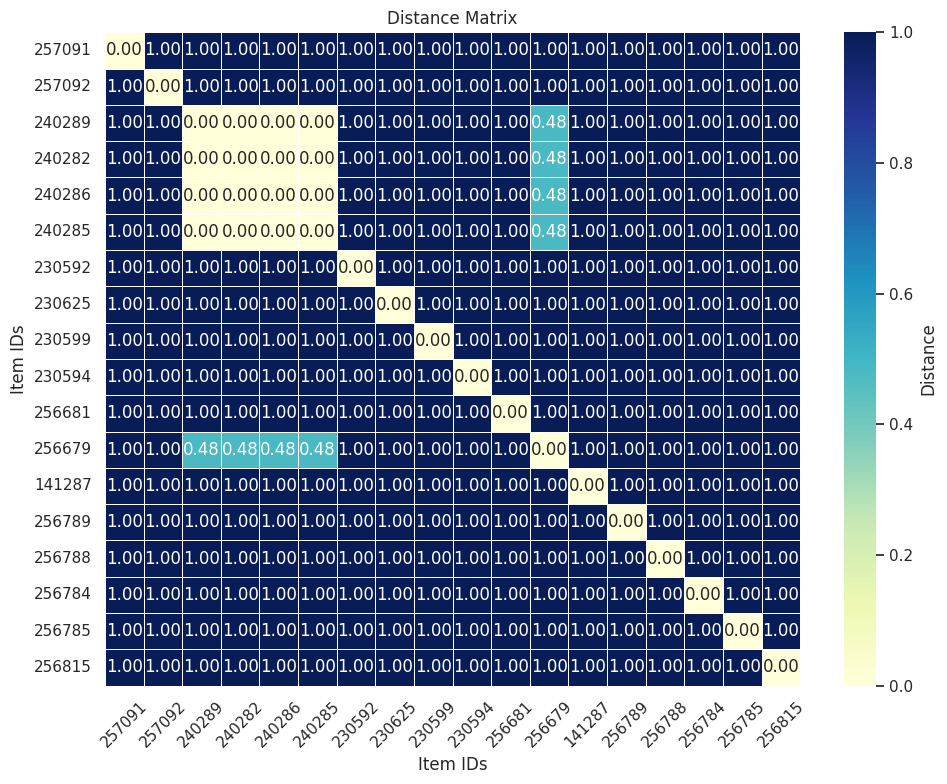

In [2]:
#distance_matrix = classifiers.compute_combined_distance_matrix(charts, chart_stats, alpha=0.2)
distance_matrix = classifiers.compute_jaccard_distance_matrix(charts, chart_stats, sigma=3.0)


# plot the distance matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 12
sns.set(style="whitegrid")
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'Distance'}, linewidths=.5)
plt.title("Distance Matrix")
plt.xlabel("Item IDs")
plt.ylabel("Item IDs")
plt.xticks(ticks=np.arange(len(itemIds)) + 0.5, labels=itemIds, rotation=45)
plt.yticks(ticks=np.arange(len(itemIds)) + 0.5, labels=itemIds, rotation=0)
plt.tight_layout()
plt.savefig('distance_matrix.png', dpi=300)
plt.show()


In [3]:
clusters, centroids, charts = classifiers.run_dbscan(charts, chart_stats,min_samples=2,
                                                     jaccard_eps=0.1, corr_eps=0.3)
#clusters = classifiers.reassign_charts(charts, clusters, centroids, 0.5)

score = classifiers.evaluate_clusters(charts, clusters)
print("score: ", score)

score:  0.0


/home/ubuntu/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/.local/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [4]:
view_source = {
    "name": "views_20250406",
    "type": "csv",
    "history_file_path": os.path.join(dg.data_dir, "history.csv.gz"),
    "trends_file_path": os.path.join(dg.data_dir, "trends.csv.gz"),
    "startep": startep,
    "endep": endep
}
import views


def plot_charts(itemIds):
    df = pd.DataFrame(itemIds, columns=['itemid'])
    v = views.get_view(view_source)
    v.show(df)

    
classes = {}
for chart_id, cluster_id in clusters.items():
    if cluster_id not in classes:
        classes[cluster_id] = []
    classes[cluster_id].append(chart_id)
print("classes: ", classes)

classes:  {-1: [257091, 257092, 230592, 230625, 230599, 230594, 256681, 256679, 141287, 256789, 256788, 256784, 256785, 256815], 1: [240289, 240282, 240286, 240285]}


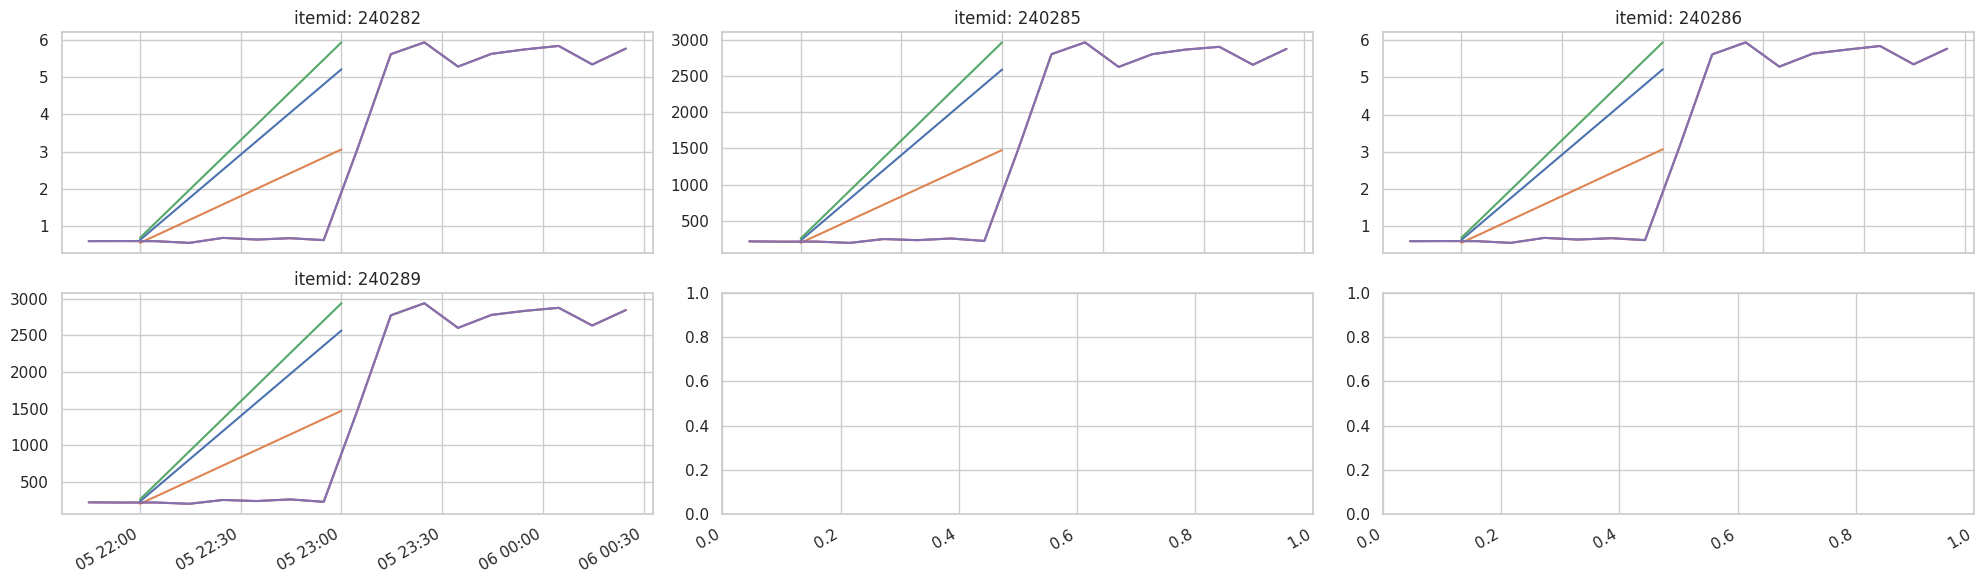

KeyError: 2

In [6]:
#plot_charts(classes[0])
plot_charts(classes[1])
plot_charts(classes[2])
plot_charts(classes[3])
plot_charts(classes[4])
plot_charts(classes[5])
plot_charts(classes[6])
plot_charts(classes[7])